# Visual Storyteller — Data Loading & Model Training

**Final Project | Image Captioning with a CNN encoder + Transformer decoder**

---

Given an image, produce a sentence that describes it. This sits at the intersection of
computer vision and natural-language generation: images are dense pixel grids, captions are
discrete token sequences with syntactic and semantic structure. The model has to bridge the two.

This notebook is the full training pipeline:

1. **Data loading & exploration** — understand the dataset before modelling it.
2. **Preprocessing** — vocabulary, tokenisation, `Dataset`/`DataLoader`s.
3. **Model definition** — an EfficientNet encoder (with learned 2-D spatial position
   embeddings) paired with a Transformer decoder that ties its input/output embeddings.
4. **Training** — AdamW with decoupled weight decay, a linear-warmup → cosine LR schedule
   stepped per batch, mixed precision, gradient clipping, label smoothing, an encoder
   freeze→fine-tune schedule, **validation-BLEU-driven checkpoint selection**, and
   **early stopping** so the model decides its own stopping epoch.
5. **Curves** — train/val loss, validation BLEU-4, and the LR schedule.

Everything is seeded and every artefact is written to `./artifacts/` so `inference.ipynb`
can reconstruct the model and evaluate on a held-out test split it never saw.

> **Design note — what changed vs. a loss-only baseline.** The single most important change
> is that the best checkpoint is chosen by **validation BLEU-4**, not by validation
> cross-entropy. With label smoothing, CE loss is a poor proxy for caption quality, and the
> lowest-loss epoch is frequently *not* the best-captioning epoch. We therefore decode the
> validation set each epoch and track the actual metric we care about. Other notable changes:
> hue jitter removed (it was actively teaching the model the wrong colours), input/output
> embedding tying, no weight decay on norms/biases/embeddings, and a smoother per-step LR
> schedule. See the markdown above each section for the rationale.

## 0. Imports & Configuration

All hyper-parameters live in one `Config` dataclass so ablations are a one-line change.

In [1]:
import os
import re
import json
import math
import time
import random
import pickle
import logging
from pathlib import Path
from dataclasses import dataclass, asdict
from collections import Counter, defaultdict
from typing import List, Tuple, Dict, Optional

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import torchvision.transforms as T

# timm is a hard dependency — a silent fallback encoder would create a weights/cfg
# mismatch that breaks inference.ipynb. Fail loudly and clearly instead.
try:
    import timm
except ImportError as e:
    raise ImportError("This project requires timm:  pip install timm") from e

logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(levelname)s | %(message)s")
logger = logging.getLogger("train")


# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.use_deterministic_algorithms(True, warn_only=True)


def seed_worker(worker_id: int) -> None:
    """Make DataLoader-worker augmentation reproducible."""
    worker_seed = torch.initial_seed() % (2 ** 32)
    np.random.seed(worker_seed)
    random.seed(worker_seed)


_g = torch.Generator()
_g.manual_seed(SEED)


@dataclass
class Config:
    # ── Paths ─────────────────────────────────────────────────────────────────
    images_dir: str = "./caption_data/images"           # folder of .jpg files
    captions_file: str = "./caption_data/captions.txt"  # image,caption (CSV) or image\tcaption (TSV)
    output_dir: str = "./artifacts"                     # all artefacts saved here

    # ── Vocabulary ────────────────────────────────────────────────────────────
    vocab_min_freq: int = 5     # Flickr8k-standard; rarer words → <UNK>. Cleaner vocab → more
                                # fluent generation and higher BLEU than min_freq=2.
    max_caption_len: int = 40   # > 99th percentile of Flickr8k caption lengths

    # ── Model ─────────────────────────────────────────────────────────────────
    encoder_name: str = "efficientnet_b3"   # any timm model that supports features_only=True
    encoder_pretrained: bool = True
    embed_dim: int = 512
    num_heads: int = 8
    num_decoder_layers: int = 4
    feedforward_dim: int = 2048
    dropout: float = 0.1
    tie_embeddings: bool = True      # share decoder input-embedding & output-projection weights
    use_spatial_pos: bool = True     # learned 2-D position embeddings on the encoder grid

    # ── Training ──────────────────────────────────────────────────────────────
    batch_size: int = 64
    num_epochs: int = 60             # CEILING — early stopping decides the real number of epochs
    warmup_freeze_epochs: int = 3    # encoder frozen for this many epochs, then fine-tuned
    warmup_lr_epochs: float = 1.0    # linear LR warmup length (in epochs) before cosine decay
    learning_rate: float = 4e-4      # peak LR for the decoder param group
    encoder_lr_multiplier: float = 0.1   # encoder LR = learning_rate * this
    weight_decay: float = 1e-2       # applied ONLY to matmul weights (not norms/biases/embeddings)
    grad_clip: float = 1.0
    label_smoothing: float = 0.1
    use_amp: bool = True             # mixed precision on CUDA

    # ── Early stopping / checkpoint selection ─────────────────────────────────
    early_stop_patience: int = 8     # stop if val BLEU-4 doesn't improve for this many epochs
    early_stop_min_delta: float = 0.05   # BLEU points considered a real improvement

    # ── Splits ────────────────────────────────────────────────────────────────
    val_split: float = 0.10
    test_split: float = 0.10         # held out entirely — only inference.ipynb touches it

    # ── Misc ──────────────────────────────────────────────────────────────────
    image_size: int = 224
    num_workers: int = 0            # set 0 on Windows/Jupyter if you hit worker issues
    device: str = "cuda" if torch.cuda.is_available() else "cpu"


cfg = Config()
Path(cfg.output_dir).mkdir(parents=True, exist_ok=True)

logger.info(f"Device: {cfg.device}")
if torch.cuda.is_available():
    logger.info(f"GPU: {torch.cuda.get_device_name(0)}")
logger.info(f"Artifacts → {cfg.output_dir}")

2026-06-30 18:09:54,487 | INFO | Device: cuda
2026-06-30 18:09:54,496 | INFO | GPU: NVIDIA GeForce RTX 4060 Laptop GPU
2026-06-30 18:09:54,497 | INFO | Artifacts → ./artifacts


## 1. Data Loading & Exploration

The dataset pairs each of the 8,000 images with five human-written captions (~40,000 strings).
Caption-length and vocabulary statistics inform `max_caption_len` and `vocab_min_freq`.
The loader handles both the TSV (`image\tcaption`) and CSV (`image,caption`) layouts the
dataset ships in, and drops any caption whose image is missing on disk.

In [2]:
def load_captions(captions_file: str, images_dir: str) -> Dict[str, List[str]]:
    """Return {image_filename: [caption, ...]}. Robust to TSV/CSV, headers, and the
    Flickr 'image.jpg#0' index notation. Entries with no image on disk are dropped."""
    HEADER_TOKENS = {"image", "image_name", "filename", "file_name", "img", "img_id"}
    path = Path(captions_file)

    if not path.exists():
        for alt in ["captions.txt", "captions.csv", "Flickr8k.token.txt",
                    "descriptions.txt", "annotations.txt"]:
            cand = path.parent / alt
            if cand.exists():
                path = cand
                logger.info(f"Using captions file: {path}")
                break
        else:
            raise FileNotFoundError(
                f"No captions file found in {path.parent}. Set cfg.captions_file."
            )

    captions_map: Dict[str, List[str]] = defaultdict(list)
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            sep = "\t" if "\t" in line else ","
            parts = line.split(sep, 1)
            if len(parts) != 2:
                continue
            img_id, caption = parts[0].strip(), parts[1].strip()
            if img_id.lower() in HEADER_TOKENS:
                continue
            img_name = img_id.split("#")[0]
            captions_map[img_name].append(caption)

    raw = len(captions_map)
    images_dir = Path(images_dir)
    captions_map = {k: v for k, v in captions_map.items() if (images_dir / k).exists()}
    if raw - len(captions_map):
        logger.warning(f"{raw - len(captions_map)} images had captions but no file on disk; dropped.")
    logger.info(f"Loaded captions for {len(captions_map):,} images.")
    return captions_map


captions_map = load_captions(cfg.captions_file, cfg.images_dir)

sample_key = next(iter(captions_map))
print(f"\nSample image: {sample_key}")
for c in captions_map[sample_key]:
    print(f"  • {c}")

2026-06-30 18:09:55,470 | INFO | Loaded captions for 8,091 images.



Sample image: 1000268201_693b08cb0e.jpg
  • A child in a pink dress is climbing up a set of stairs in an entry way .
  • A girl going into a wooden building .
  • A little girl climbing into a wooden playhouse .
  • A little girl climbing the stairs to her playhouse .
  • A little girl in a pink dress going into a wooden cabin .


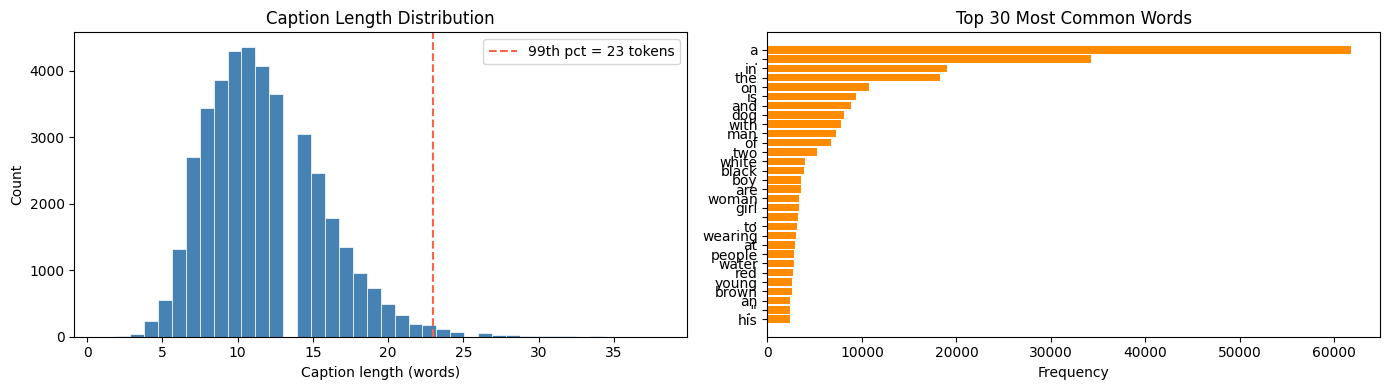


Images:            8,091
Captions:          40,455
Avg caption len:   11.8 words
99th pct len:      23 words   (max_caption_len = 40)
Unique raw tokens: 9,180


In [3]:
# ── Exploratory analysis ──────────────────────────────────────────────────────
all_captions = [c for caps in captions_map.values() for c in caps]
caption_lengths = [len(c.split()) for c in all_captions]
words = [w.lower() for c in all_captions for w in c.split()]
word_freq = Counter(words)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(caption_lengths, bins=40, color="steelblue", edgecolor="white", linewidth=0.5)
p99 = np.percentile(caption_lengths, 99)
axes[0].axvline(p99, color="tomato", ls="--", label=f"99th pct = {p99:.0f} tokens")
axes[0].set(xlabel="Caption length (words)", ylabel="Count", title="Caption Length Distribution")
axes[0].legend()

top = word_freq.most_common(30)
ws, fs = zip(*top)
axes[1].barh(list(reversed(ws)), list(reversed(fs)), color="darkorange")
axes[1].set(xlabel="Frequency", title="Top 30 Most Common Words")
plt.tight_layout()
plt.savefig(f"{cfg.output_dir}/eda_distributions.png", dpi=120)
plt.show()

print(f"\nImages:            {len(captions_map):,}")
print(f"Captions:          {len(all_captions):,}")
print(f"Avg caption len:   {np.mean(caption_lengths):.1f} words")
print(f"99th pct len:      {p99:.0f} words   (max_caption_len = {cfg.max_caption_len})")
print(f"Unique raw tokens: {len(word_freq):,}")

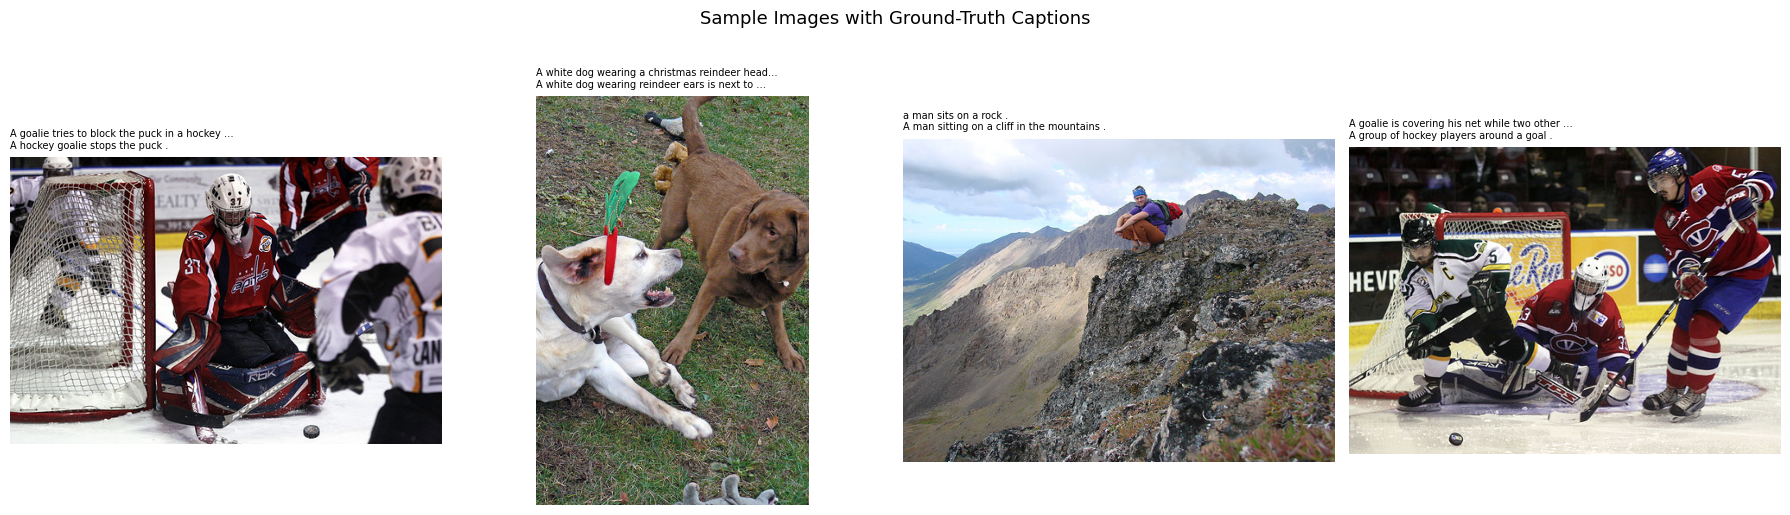

In [4]:
# ── A few image/caption pairs ─────────────────────────────────────────────────
_rng = random.Random(SEED)
sample_keys = _rng.sample(list(captions_map.keys()), 4)
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, name in zip(axes, sample_keys):
    ax.imshow(Image.open(Path(cfg.images_dir) / name).convert("RGB"))
    ax.set_title("\n".join(c[:45] + ("…" if len(c) > 45 else "") for c in captions_map[name][:2]),
                 fontsize=7, loc="left")
    ax.axis("off")
plt.suptitle("Sample Images with Ground-Truth Captions", y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig(f"{cfg.output_dir}/eda_samples.png", dpi=120, bbox_inches="tight")
plt.show()

## 2. Train / Validation / Test Split

A **three-way image-level split** is created *before* the vocabulary is built:

- **No vocab leakage** — the vocabulary is built from training captions only.
- **Clean evaluation roles** — the **val** set is decoded each epoch to pick the best
  checkpoint and to drive early stopping; the **test** set is sealed until `inference.ipynb`.
  Splitting at the *image* level guarantees that the five captions of an image never straddle
  two splits.

The split uses an explicit seeded RNG so it is stable regardless of cell execution order, and
is persisted to `artifacts/split.json`.

In [5]:
rng = random.Random(SEED)
all_images = list(captions_map.keys())
rng.shuffle(all_images)

n = len(all_images)
n_test = int(n * cfg.test_split)
n_val = int(n * cfg.val_split)
test_images = set(all_images[:n_test])
val_images = set(all_images[n_test:n_test + n_val])
train_images = set(all_images[n_test + n_val:])

train_captions = {k: captions_map[k] for k in train_images}
val_captions = {k: captions_map[k] for k in val_images}
test_captions = {k: captions_map[k] for k in test_images}

with open(f"{cfg.output_dir}/split.json", "w") as f:
    json.dump({"train_images": sorted(train_images),
               "val_images": sorted(val_images),
               "test_images": sorted(test_images)}, f, indent=2)

assert not (train_images & val_images) and not (train_images & test_images) and not (val_images & test_images)
print(f"Train: {len(train_images):,}  |  Val: {len(val_images):,}  |  Test: {len(test_images):,}")
print("✓ No image overlap between splits — split saved to artifacts/split.json")

Train: 6,473  |  Val: 809  |  Test: 809
✓ No image overlap between splits — split saved to artifacts/split.json


## 3. Vocabulary & Text Preprocessing

A word-level vocabulary built from **training captions only**. Words seen fewer than
`vocab_min_freq` times map to `<UNK>`. Special tokens: `<PAD>`=0, `<SOS>`=1, `<EOS>`=2, `<UNK>`=3.

In [6]:
class Vocabulary:
    PAD, SOS, EOS, UNK = "<PAD>", "<SOS>", "<EOS>", "<UNK>"

    def __init__(self, min_freq: int = 5):
        self.min_freq = min_freq
        self.itos: List[str] = []
        self.stoi: Dict[str, int] = {}

    @staticmethod
    def tokenize(text: str) -> List[str]:
        text = re.sub(r"[^a-z0-9']+", " ", text.lower().strip())
        return text.split()

    def build(self, captions: List[str]) -> None:
        freq = Counter()
        for c in captions:
            freq.update(self.tokenize(c))
        specials = [self.PAD, self.SOS, self.EOS, self.UNK]
        kept = sorted(w for w, f in freq.items() if f >= self.min_freq)
        self.itos = specials + kept
        self.stoi = {t: i for i, t in enumerate(self.itos)}
        pruned = sum(1 for f in freq.values() if f < self.min_freq)
        logger.info(f"Vocabulary: {len(self.itos):,} tokens (min_freq={self.min_freq}, pruned {pruned:,} rare).")

    def encode(self, caption: str, max_len: Optional[int] = None) -> List[int]:
        toks = self.tokenize(caption)
        if max_len is not None:
            toks = toks[: max_len - 2]      # leave room for SOS/EOS
        unk = self.stoi[self.UNK]
        return [self.stoi[self.SOS]] + [self.stoi.get(t, unk) for t in toks] + [self.stoi[self.EOS]]

    def decode(self, indices: List[int], skip_special: bool = True) -> str:
        specials = {self.PAD, self.SOS, self.EOS, self.UNK}
        out = []
        for idx in indices:
            tok = self.itos[idx] if 0 <= idx < len(self.itos) else self.UNK
            if tok == self.EOS:
                break
            if skip_special and tok in specials:
                continue
            out.append(tok)
        return " ".join(out)

    @property
    def pad_idx(self): return self.stoi[self.PAD]
    @property
    def sos_idx(self): return self.stoi[self.SOS]
    @property
    def eos_idx(self): return self.stoi[self.EOS]
    def __len__(self): return len(self.itos)

    def save(self, path: str) -> None:
        with open(path, "wb") as f:
            pickle.dump({"itos": self.itos, "stoi": self.stoi, "min_freq": self.min_freq}, f)
        logger.info(f"Vocabulary saved → {path}")

    @classmethod
    def load(cls, path: str) -> "Vocabulary":
        with open(path, "rb") as f:
            d = pickle.load(f)
        v = cls(min_freq=d["min_freq"]); v.itos = d["itos"]; v.stoi = d["stoi"]
        return v


train_all_captions = [c for caps in train_captions.values() for c in caps]
vocab = Vocabulary(min_freq=cfg.vocab_min_freq)
vocab.build(train_all_captions)
vocab.save(f"{cfg.output_dir}/vocab.pkl")
print(f"Vocab size {len(vocab):,} | PAD={vocab.pad_idx} SOS={vocab.sos_idx} EOS={vocab.eos_idx} UNK={vocab.stoi['<UNK>']}")

2026-06-30 18:09:56,984 | INFO | Vocabulary: 2,663 tokens (min_freq=5, pruned 5,001 rare).
2026-06-30 18:09:56,984 | INFO | Vocabulary saved → ./artifacts/vocab.pkl


Vocab size 2,663 | PAD=0 SOS=1 EOS=2 UNK=3


## 4. Datasets, Augmentation & DataLoaders

Each (image, caption) pair is an independent example, so 8,000 images yield ~32,000 training
pairs — the five captions per image act as natural augmentation of the *language* target.

**Image augmentation, deliberately conservative.** A baseline that includes `ColorJitter(hue=…)`
is actively harmful for captioning: many captions name colours ("a **red** ball", "a man in a
**blue** shirt"), and shifting hue trains the model to associate the wrong colour word with an
image. We therefore **remove hue jitter entirely** and keep only label-preserving augmentations:
`RandomResizedCrop` (mild scale), horizontal flip, and gentle brightness/contrast. Train and eval
share the standard resize-256 → centre-crop-224 field of view so there is no train/test mismatch.

In [7]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]


def build_transforms(split: str, image_size: int) -> T.Compose:
    if split == "train":
        return T.Compose([
            T.RandomResizedCrop(image_size, scale=(0.8, 1.0), ratio=(0.85, 1.15)),
            T.RandomHorizontalFlip(0.5),
            T.ColorJitter(brightness=0.15, contrast=0.15),   # NO hue/saturation jitter
            T.ToTensor(),
            T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        ])
    return T.Compose([                                       # val / test / inference
        T.Resize(int(image_size * 1.14)),
        T.CenterCrop(image_size),
        T.ToTensor(),
        T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])


class CaptionDataset(Dataset):
    """One (image_tensor, caption_ids) per (image, caption) pair."""
    def __init__(self, cmap, images_dir, vocab, transform, max_len):
        self.images_dir = Path(images_dir)
        self.vocab, self.transform, self.max_len = vocab, transform, max_len
        self.pairs: List[Tuple[str, str]] = [(img, cap) for img, caps in cmap.items() for cap in caps]

    def __len__(self): return len(self.pairs)

    def __getitem__(self, i):
        name, caption = self.pairs[i]
        img = Image.open(self.images_dir / name).convert("RGB")
        img = self.transform(img)
        ids = torch.tensor(self.vocab.encode(caption, self.max_len), dtype=torch.long)
        return img, ids


def collate_fn(batch):
    imgs, caps = zip(*batch)
    imgs = torch.stack(imgs, 0)
    caps = pad_sequence(caps, batch_first=True, padding_value=vocab.pad_idx)
    return imgs, caps


class ImageOnlyDataset(Dataset):
    """For validation decoding: yields (image_tensor, image_name) for each UNIQUE image."""
    def __init__(self, image_names, images_dir, transform):
        self.names = list(image_names)
        self.images_dir = Path(images_dir)
        self.transform = transform

    def __len__(self): return len(self.names)

    def __getitem__(self, i):
        name = self.names[i]
        img = Image.open(self.images_dir / name).convert("RGB")
        return self.transform(img), name


train_tf = build_transforms("train", cfg.image_size)
eval_tf = build_transforms("eval", cfg.image_size)

train_dataset = CaptionDataset(train_captions, cfg.images_dir, vocab, train_tf, cfg.max_caption_len)
val_unique_names = sorted(val_captions.keys())
val_image_dataset = ImageOnlyDataset(val_unique_names, cfg.images_dir, eval_tf)

train_loader = DataLoader(
    train_dataset, batch_size=cfg.batch_size, shuffle=True,
    num_workers=cfg.num_workers, collate_fn=collate_fn, pin_memory=True, drop_last=True,
    worker_init_fn=seed_worker, generator=_g,
    persistent_workers=cfg.num_workers > 0,
)
val_image_loader = DataLoader(
    val_image_dataset, batch_size=cfg.batch_size, shuffle=False,
    num_workers=cfg.num_workers, pin_memory=True, worker_init_fn=seed_worker,
    persistent_workers=cfg.num_workers > 0,
)
print(f"Train pairs: {len(train_dataset):,} | Val images (decoded each epoch): {len(val_image_dataset):,}")

Train pairs: 32,365 | Val images (decoded each epoch): 809


## 5. Model Definition

**Encoder.** EfficientNet-B3 (ImageNet-pretrained) with the classifier removed; we take the
last feature map (a `H'×W'` grid of channel vectors), project it to `embed_dim`, and add a
**learned 2-D spatial position embedding** so the decoder's cross-attention can reason about
*where* things are rather than treating the grid as an unordered bag of features.

**Decoder.** A pre-norm Transformer decoder. Token embeddings attend causally to previous
tokens (masked self-attention) and to the image grid (cross-attention). Positional information
for the text stream is sinusoidal. The output projection **shares its weights with the input
token embedding** (weight tying) — a standard trick that regularises the model and consistently
improves language-generation quality.

We also provide `generate()` with **greedy** and **length-normalised beam search** decoding,
used both for in-training validation BLEU and at inference time.

In [8]:
def causal_mask(T_len: int, device) -> torch.Tensor:
    """Upper-triangular float mask (-inf above diagonal) — version-agnostic."""
    m = torch.full((T_len, T_len), float("-inf"), device=device)
    return torch.triu(m, diagonal=1)


class ImageEncoder(nn.Module):
    """timm backbone → (B, S, embed_dim) sequence of spatial features + learned 2-D pos emb."""
    def __init__(self, model_name, embed_dim, pretrained=True, image_size=224,
                 use_spatial_pos=True, dropout=0.1):
        super().__init__()
        self.embed_dim = embed_dim
        self.backbone = timm.create_model(model_name, pretrained=pretrained, features_only=True)
        with torch.no_grad():
            dummy = torch.zeros(1, 3, image_size, image_size)
            feat = self.backbone(dummy)[-1]
            self.feat_channels = feat.shape[1]
            self.num_tokens = feat.shape[2] * feat.shape[3]
        self.proj = nn.Linear(self.feat_channels, embed_dim)
        self.norm = nn.LayerNorm(embed_dim)
        self.dropout = nn.Dropout(dropout)
        if use_spatial_pos:
            self.spatial_pos = nn.Parameter(torch.zeros(1, self.num_tokens, embed_dim))
            nn.init.trunc_normal_(self.spatial_pos, std=0.02)
        else:
            self.register_parameter("spatial_pos", None)

    def forward(self, images):
        x = self.backbone(images)[-1]                 # (B, C, H', W')
        B, C, H, W = x.shape
        x = x.permute(0, 2, 3, 1).reshape(B, H * W, C)  # (B, S, C)
        x = self.proj(x)
        if self.spatial_pos is not None:
            x = x + self.spatial_pos[:, : x.size(1)]
        x = self.norm(x)
        return self.dropout(x)                        # (B, S, embed_dim)

    def freeze(self):
        for p in self.backbone.parameters():
            p.requires_grad = False

    def unfreeze(self):
        for p in self.backbone.parameters():
            p.requires_grad = True


class PositionalEncoding(nn.Module):
    """Sinusoidal positional encoding for the text stream."""
    def __init__(self, embed_dim, dropout=0.1, max_len=512):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe = torch.zeros(max_len, embed_dim)
        pos = torch.arange(max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, embed_dim, 2).float() * (-math.log(10000.0) / embed_dim))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return self.dropout(x + self.pe[:, : x.size(1)])


class CaptionDecoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_heads, num_layers,
                 feedforward_dim, dropout, pad_idx, tie_embeddings=True, max_len=512):
        super().__init__()
        self.embed_dim, self.pad_idx = embed_dim, pad_idx
        self.token_embed = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.pos_enc = PositionalEncoding(embed_dim, dropout, max_len)
        layer = nn.TransformerDecoderLayer(
            d_model=embed_dim, nhead=num_heads, dim_feedforward=feedforward_dim,
            dropout=dropout, batch_first=True, norm_first=True, activation="gelu",
        )
        self.decoder = nn.TransformerDecoder(layer, num_layers=num_layers, norm=nn.LayerNorm(embed_dim))
        self.fc_out = nn.Linear(embed_dim, vocab_size)
        self._init_weights()
        if tie_embeddings:
            self.fc_out.weight = self.token_embed.weight   # share input/output embeddings

    def _init_weights(self):
        nn.init.trunc_normal_(self.token_embed.weight, std=0.02)
        nn.init.xavier_uniform_(self.fc_out.weight)
        nn.init.zeros_(self.fc_out.bias)
        with torch.no_grad():                              # keep padding row at zero
            self.token_embed.weight[self.pad_idx].zero_()

    def forward(self, tgt, memory, tgt_key_padding_mask=None):
        mask = causal_mask(tgt.size(1), tgt.device)
        x = self.token_embed(tgt) * math.sqrt(self.embed_dim)
        x = self.pos_enc(x)
        out = self.decoder(x, memory, tgt_mask=mask, tgt_key_padding_mask=tgt_key_padding_mask)
        return self.fc_out(out)


class ImageCaptioningModel(nn.Module):
    def __init__(self, encoder: ImageEncoder, decoder: CaptionDecoder):
        super().__init__()
        self.encoder, self.decoder = encoder, decoder

    def forward(self, images, captions):
        memory = self.encoder(images)
        tgt = captions[:, :-1]
        pad_mask = tgt == self.decoder.pad_idx
        return self.decoder(tgt, memory, tgt_key_padding_mask=pad_mask)

    # ── Decoding ──────────────────────────────────────────────────────────────
    @torch.no_grad()
    def generate(self, images, sos_idx, eos_idx, max_len=40, beam_size=1, length_penalty=0.7):
        self.eval()
        memory = self.encoder(images)
        if beam_size == 1:
            return self._greedy(memory, sos_idx, eos_idx, max_len)
        return [self._beam(memory[i:i + 1], sos_idx, eos_idx, max_len, beam_size, length_penalty)
                for i in range(memory.size(0))]

    @torch.no_grad()
    def _greedy(self, memory, sos_idx, eos_idx, max_len):
        B, device = memory.size(0), memory.device
        tokens = torch.full((B, 1), sos_idx, dtype=torch.long, device=device)
        done = torch.zeros(B, dtype=torch.bool, device=device)
        out = [[] for _ in range(B)]
        for _ in range(max_len):
            logits = self.decoder(tokens, memory)
            nxt = logits[:, -1, :].argmax(-1)
            tokens = torch.cat([tokens, nxt.unsqueeze(1)], 1)
            for b in range(B):
                if not done[b]:
                    if nxt[b].item() == eos_idx:
                        done[b] = True
                    else:
                        out[b].append(nxt[b].item())
            if done.all():
                break
        return out

    @torch.no_grad()
    def _beam(self, memory, sos_idx, eos_idx, max_len, beam_size, alpha):
        device = memory.device
        beams = [(0.0, [sos_idx])]           # (cumulative log-prob, tokens)
        completed = []

        def lp(length):                      # GNMT length penalty
            return ((5 + length) / 6) ** alpha

        for _ in range(max_len):
            cands = []
            for score, seq in beams:
                if seq[-1] == eos_idx:
                    completed.append((score, seq))
                    continue
                inp = torch.tensor([seq], dtype=torch.long, device=device)
                logits = self.decoder(inp, memory)[:, -1, :]
                logp = F.log_softmax(logits, -1).squeeze(0)
                topv, topi = logp.topk(beam_size)
                for v, i in zip(topv.tolist(), topi.tolist()):
                    cands.append((score + v, seq + [i]))
            if not cands:
                break
            cands.sort(key=lambda x: x[0] / lp(len(x[1])), reverse=True)
            beams = cands[:beam_size]
            if all(s[-1] == eos_idx for _, s in beams):
                completed.extend(beams)
                break
        completed.extend(beams)
        best = max(completed, key=lambda x: x[0] / lp(len(x[1])))
        return [t for t in best[1] if t not in (sos_idx, eos_idx)]


# ── Instantiate ───────────────────────────────────────────────────────────────
encoder = ImageEncoder(cfg.encoder_name, cfg.embed_dim, cfg.encoder_pretrained,
                       cfg.image_size, cfg.use_spatial_pos, cfg.dropout)
decoder = CaptionDecoder(len(vocab), cfg.embed_dim, cfg.num_heads, cfg.num_decoder_layers,
                         cfg.feedforward_dim, cfg.dropout, vocab.pad_idx,
                         cfg.tie_embeddings, cfg.max_caption_len + 10)
model = ImageCaptioningModel(encoder, decoder).to(cfg.device)

total = sum(p.numel() for p in model.parameters())
print(f"Encoder grid tokens: {encoder.num_tokens} | feat channels: {encoder.feat_channels}")
print(f"Total parameters: {total:,}")

2026-06-30 18:09:57,332 | INFO | Loading pretrained weights from Hugging Face hub (timm/efficientnet_b3.ra2_in1k)
2026-06-30 18:09:57,850 | INFO | HTTP Request: HEAD https://huggingface.co/timm/efficientnet_b3.ra2_in1k/resolve/main/model.safetensors "HTTP/1.1 302 Found"
2026-06-30 18:09:57,867 | INFO | [timm/efficientnet_b3.ra2_in1k] Safe alternative available for 'pytorch_model.bin' (as 'model.safetensors'). Loading weights using safetensors.
2026-06-30 18:09:58,065 | WARNING | Unexpected keys (bn2.num_batches_tracked, bn2.bias, bn2.running_mean, bn2.running_var, bn2.weight, classifier.bias, classifier.weight, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.


Encoder grid tokens: 49 | feat channels: 384
Total parameters: 28,509,839


## 6. Training Strategy

- **Loss** — cross-entropy with **label smoothing 0.1** (better-calibrated, less over-confident).
- **Optimiser** — AdamW with **decoupled weight decay applied only to matmul weights**; biases,
  LayerNorm parameters and embeddings are excluded (decaying them hurts). The encoder uses a
  **10× smaller LR** than the decoder.
- **Schedule** — **linear warmup → cosine decay**, stepped **per batch**. Smoother than
  warm-restarts and pairs cleanly with early stopping (no LR "bumps" to confuse the stopping rule).
- **Encoder freeze → fine-tune** — the encoder is frozen for `warmup_freeze_epochs` so the random
  decoder doesn't push noisy gradients into pretrained features, then unfrozen for end-to-end
  fine-tuning.
- **Mixed precision + gradient clipping** — faster training, stable Transformer gradients.
- **Selection & stopping** — after each epoch we **decode the validation set and compute BLEU-4**;
  the best-BLEU checkpoint is saved and **early stopping** halts training once BLEU-4 plateaus.

In [9]:
criterion = nn.CrossEntropyLoss(ignore_index=vocab.pad_idx, label_smoothing=cfg.label_smoothing)


def build_param_groups(model, cfg):
    """Split parameters into {encoder, decoder} × {decay, no_decay}.
    No weight decay on biases, LayerNorm, embeddings, or the learned spatial position emb."""
    enc_decay, enc_no, dec_decay, dec_no = [], [], [], []
    for name, p in model.named_parameters():
        if not p.requires_grad and "backbone" not in name:
            pass  # still register frozen encoder params so they train after unfreeze
        is_encoder = name.startswith("encoder.backbone")
        no_decay = (p.ndim <= 1) or ("bias" in name) or ("norm" in name.lower()) \
            or ("token_embed" in name) or ("spatial_pos" in name) or ("pe" in name.split("."))
        if is_encoder:
            (enc_no if no_decay else enc_decay).append(p)
        else:
            (dec_no if no_decay else dec_decay).append(p)
    lr, elr = cfg.learning_rate, cfg.learning_rate * cfg.encoder_lr_multiplier
    return [
        {"params": dec_decay, "lr": lr, "weight_decay": cfg.weight_decay},
        {"params": dec_no, "lr": lr, "weight_decay": 0.0},
        {"params": enc_decay, "lr": elr, "weight_decay": cfg.weight_decay},
        {"params": enc_no, "lr": elr, "weight_decay": 0.0},
    ]


optimizer = torch.optim.AdamW(build_param_groups(model, cfg), betas=(0.9, 0.98), eps=1e-9)

steps_per_epoch = len(train_loader)
total_steps = steps_per_epoch * cfg.num_epochs
warmup_steps = int(steps_per_epoch * cfg.warmup_lr_epochs)
min_lr_ratio = 1e-6 / cfg.learning_rate


def lr_lambda(step):
    if step < warmup_steps:
        return step / max(1, warmup_steps)
    prog = (step - warmup_steps) / max(1, total_steps - warmup_steps)
    prog = min(1.0, prog)
    return min_lr_ratio + (1 - min_lr_ratio) * 0.5 * (1 + math.cos(math.pi * prog))


scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

# Mixed-precision setup (new torch.amp API, with a fallback for older PyTorch)
amp_enabled = cfg.use_amp and cfg.device == "cuda"
try:
    from torch.amp import autocast as _autocast, GradScaler as _GradScaler
    scaler = _GradScaler("cuda", enabled=amp_enabled)
    def autocast_ctx():
        return _autocast("cuda", enabled=amp_enabled)
except Exception:
    scaler = torch.cuda.amp.GradScaler(enabled=amp_enabled)
    def autocast_ctx():
        return torch.cuda.amp.autocast(enabled=amp_enabled)

model.encoder.freeze()
logger.info("Encoder frozen for warmup phase.")

2026-06-30 18:09:59,267 | INFO | Encoder frozen for warmup phase.


In [10]:
# ── Lightweight, dependency-free corpus BLEU-4 for in-training monitoring ──────
def _ngram_counts(tokens, n):
    return Counter(tuple(tokens[i:i + n]) for i in range(len(tokens) - n + 1))


def corpus_bleu4(list_of_refs: List[List[List[str]]], hyps: List[List[str]], max_n: int = 4) -> float:
    """Smoothed corpus BLEU-4 in %. references[i] = list of tokenised reference captions."""
    p_num, p_den = [0] * max_n, [0] * max_n
    hyp_len = ref_len = 0
    for refs, hyp in zip(list_of_refs, hyps):
        hyp_len += len(hyp)
        ref_len += min((len(r) for r in refs), key=lambda l: (abs(l - len(hyp)), l)) if refs else 0
        for nn_ in range(1, max_n + 1):
            h = _ngram_counts(hyp, nn_)
            if not h:
                continue
            maxref = Counter()
            for r in refs:
                for g, c in _ngram_counts(r, nn_).items():
                    if c > maxref[g]:
                        maxref[g] = c
            p_num[nn_ - 1] += sum(min(c, maxref[g]) for g, c in h.items())
            p_den[nn_ - 1] += sum(h.values())
    precisions = []
    for i in range(max_n):
        if p_den[i] == 0:
            precisions.append(0.0)
        elif p_num[i] == 0:
            precisions.append(1.0 / (2 * p_den[i]))         # epsilon smoothing
        else:
            precisions.append(p_num[i] / p_den[i])
    geo = math.exp(sum(math.log(p) for p in precisions) / max_n) if min(precisions) > 0 else 0.0
    bp = 1.0 if hyp_len > ref_len else math.exp(1 - ref_len / max(hyp_len, 1))
    return bp * geo * 100.0


# Pre-tokenise validation references once (image_name → list of token lists)
val_refs_tok = {name: [Vocabulary.tokenize(c) for c in caps] for name, caps in val_captions.items()}


@torch.no_grad()
def evaluate_val_bleu(model) -> float:
    """Greedy-decode every validation image and return corpus BLEU-4 (%)."""
    model.eval()
    refs, hyps = [], []
    for imgs, names in val_image_loader:
        imgs = imgs.to(cfg.device, non_blocking=True)
        with autocast_ctx():
            token_lists = model.generate(imgs, vocab.sos_idx, vocab.eos_idx,
                                         max_len=cfg.max_caption_len, beam_size=1)
        for name, ids in zip(names, token_lists):
            hyps.append(vocab.decode(ids).split())
            refs.append(val_refs_tok[name])
    return corpus_bleu4(refs, hyps)


def train_one_epoch(model, loader) -> float:
    model.train()
    running = 0.0
    for imgs, caps in tqdm(loader, desc="  train", leave=False):
        imgs = imgs.to(cfg.device, non_blocking=True)
        caps = caps.to(cfg.device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with autocast_ctx():
            logits = model(imgs, caps)               # (B, T-1, V)
            targets = caps[:, 1:]
            loss = criterion(logits.reshape(-1, logits.size(-1)), targets.reshape(-1))
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()                             # per-batch LR schedule
        running += loss.item()
    return running / len(loader)


@torch.no_grad()
def validate_loss(model, loader) -> float:
    model.eval()
    running = 0.0
    for imgs, caps in loader:
        imgs = imgs.to(cfg.device, non_blocking=True)
        caps = caps.to(cfg.device, non_blocking=True)
        with autocast_ctx():
            logits = model(imgs, caps)
            targets = caps[:, 1:]
            loss = criterion(logits.reshape(-1, logits.size(-1)), targets.reshape(-1))
        running += loss.item()
    return running / len(loader)


# A small loss-only val loader (teacher-forced) for monitoring CE on val pairs
val_loss_loader = DataLoader(
    CaptionDataset(val_captions, cfg.images_dir, vocab, eval_tf, cfg.max_caption_len),
    batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers,
    collate_fn=collate_fn, pin_memory=True, persistent_workers=cfg.num_workers > 0,
)

## 7. Training Loop

Each epoch: train → compute teacher-forced val loss → **decode val set for BLEU-4**. The best
checkpoint is the one with the **highest val BLEU-4**; early stopping ends training when BLEU-4
stops improving for `early_stop_patience` epochs. The chosen number of epochs is therefore an
*output* of training, not a hard-coded value.

In [11]:
history = {"train_loss": [], "val_loss": [], "val_bleu4": [], "lr": []}
best_bleu, best_epoch, epochs_no_improve = -1.0, 0, 0
best_path = f"{cfg.output_dir}/best_model.pt"
last_path = f"{cfg.output_dir}/last_model.pt"

logger.info(f"Training up to {cfg.num_epochs} epochs (early stop patience={cfg.early_stop_patience}).")

for epoch in range(1, cfg.num_epochs + 1):
    t0 = time.time()
    if epoch == cfg.warmup_freeze_epochs + 1:
        model.encoder.unfreeze()
        logger.info(f"Epoch {epoch}: encoder unfrozen — fine-tuning end-to-end.")

    train_loss = train_one_epoch(model, train_loader)
    val_loss = validate_loss(model, val_loss_loader)
    val_bleu = evaluate_val_bleu(model)
    lr_now = optimizer.param_groups[0]["lr"]

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_bleu4"].append(val_bleu)
    history["lr"].append(lr_now)

    logger.info(f"Epoch {epoch:3d}/{cfg.num_epochs} | train {train_loss:.4f} | "
                f"val {val_loss:.4f} | val BLEU-4 {val_bleu:5.2f} | lr {lr_now:.2e} | {time.time()-t0:.0f}s")

    # checkpoint selection by val BLEU-4 (the metric we actually care about)
    if val_bleu > best_bleu + cfg.early_stop_min_delta:
        best_bleu, best_epoch, epochs_no_improve = val_bleu, epoch, 0
        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "val_bleu4": val_bleu,
            "val_loss": val_loss,
            "cfg": asdict(cfg),
            "vocab_size": len(vocab),
        }, best_path)
        logger.info(f"  ✓ New best val BLEU-4 {val_bleu:.2f} — checkpoint saved.")
    else:
        epochs_no_improve += 1

    torch.save({"epoch": epoch, "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "scheduler_state_dict": scheduler.state_dict(),
                "val_bleu4": val_bleu, "cfg": asdict(cfg)}, last_path)

    if epochs_no_improve >= cfg.early_stop_patience:
        logger.info(f"Early stopping at epoch {epoch} — no BLEU-4 improvement for "
                    f"{cfg.early_stop_patience} epochs. Best was epoch {best_epoch} ({best_bleu:.2f}).")
        break

with open(f"{cfg.output_dir}/training_history.json", "w") as f:
    json.dump(history, f, indent=2)
logger.info(f"Training complete. Best val BLEU-4 = {best_bleu:.2f} at epoch {best_epoch}.")

2026-06-30 18:09:59,333 | INFO | Training up to 60 epochs (early stop patience=8).


  train:   0%|          | 0/505 [00:00<?, ?it/s]

c:\Users\tornike\miniconda3\envs\dl\Lib\site-packages\torch\nn\modules\linear.py:125: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\Context.cpp:208.)
  return F.linear(input, self.weight, self.bias)
c:\Users\tornike\miniconda3\envs\dl\Lib\site-packages\torch\nn\functional.py:5849: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.w

  train:   0%|          | 0/505 [00:00<?, ?it/s]

2026-06-30 18:17:55,971 | INFO | Epoch   2/60 | train 3.6610 | val 3.5973 | val BLEU-4 16.33 | lr 4.00e-04 | 236s
2026-06-30 18:17:56,138 | INFO |   ✓ New best val BLEU-4 16.33 — checkpoint saved.


...

2026-06-30 18:57:04,820 | INFO | Epoch  10/60 | train 2.4417 | val 3.6593 | val BLEU-4 17.99 | lr 3.78e-04 | 299s


  train:   0%|          | 0/505 [00:00<?, ?it/s]

2026-06-30 19:02:02,855 | INFO | Epoch  11/60 | train 2.3566 | val 3.6977 | val BLEU-4 16.50 | lr 3.72e-04 | 298s


  train:   0%|          | 0/505 [00:00<?, ?it/s]

2026-06-30 19:07:02,323 | INFO | Epoch  12/60 | train 2.2771 | val 3.7495 | val BLEU-4 15.68 | lr 3.67e-04 | 299s
2026-06-30 19:07:02,751 | INFO | Early stopping at epoch 12 — no BLEU-4 improvement for 8 epochs. Best was epoch 4 (19.60).
2026-06-30 19:07:02,754 | INFO | Training complete. Best val BLEU-4 = 19.60 at epoch 4.


## 8. Training Progress

Three things to look for: (1) train **and** val loss decreasing together (learning, not
overfitting); (2) **val BLEU-4 rising then plateauing** — the plateau is exactly where early
stopping fires and where `best_model.pt` was taken; (3) a clean warmup→cosine LR curve.

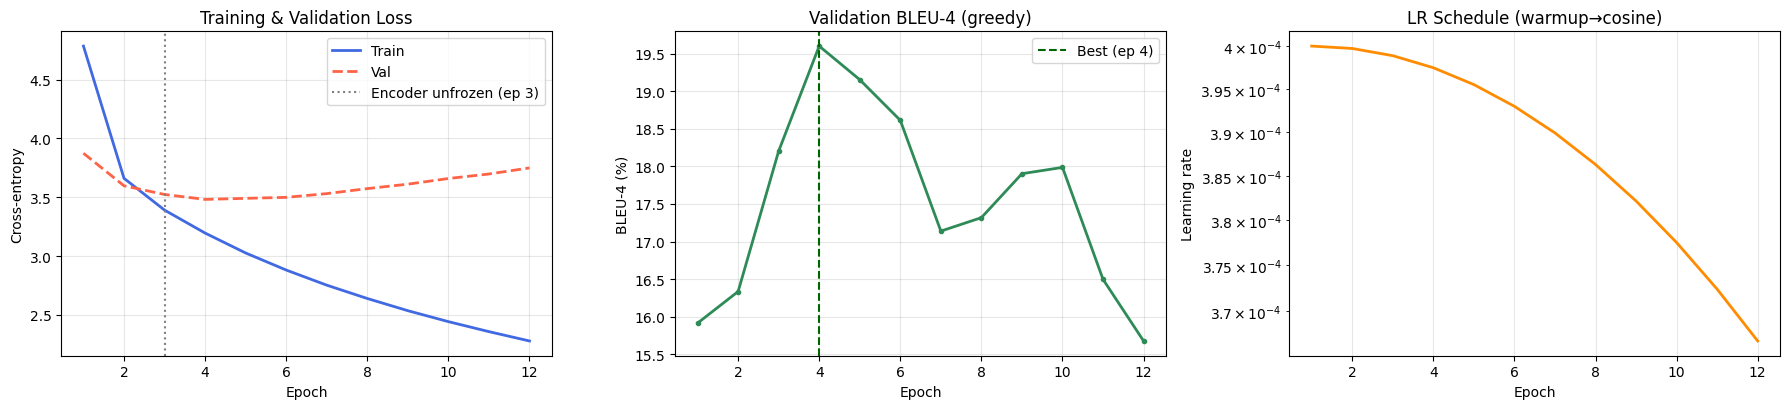

Best val BLEU-4: 19.60  at epoch 4
Best val loss:   3.4815 (perplexity ≈ 32.5)


In [12]:
ep = range(1, len(history["train_loss"]) + 1)
fig, axes = plt.subplots(1, 3, figsize=(18, 4.2))

axes[0].plot(ep, history["train_loss"], color="royalblue", lw=2, label="Train")
axes[0].plot(ep, history["val_loss"], color="tomato", lw=2, ls="--", label="Val")
axes[0].axvline(cfg.warmup_freeze_epochs, color="grey", ls=":",
                label=f"Encoder unfrozen (ep {cfg.warmup_freeze_epochs})")
axes[0].set(xlabel="Epoch", ylabel="Cross-entropy", title="Training & Validation Loss")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(ep, history["val_bleu4"], color="seagreen", lw=2, marker="o", ms=3)
if best_epoch:
    axes[1].axvline(best_epoch, color="darkgreen", ls="--", label=f"Best (ep {best_epoch})")
    axes[1].legend()
axes[1].set(xlabel="Epoch", ylabel="BLEU-4 (%)", title="Validation BLEU-4 (greedy)")
axes[1].grid(alpha=0.3)

axes[2].plot(ep, history["lr"], color="darkorange", lw=2)
axes[2].set(xlabel="Epoch", ylabel="Learning rate", title="LR Schedule (warmup→cosine)")
axes[2].set_yscale("log"); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{cfg.output_dir}/training_curves.png", dpi=140)
plt.show()

print(f"Best val BLEU-4: {best_bleu:.2f}  at epoch {best_epoch}")
print(f"Best val loss:   {min(history['val_loss']):.4f} (perplexity ≈ {math.exp(min(history['val_loss'])):.1f})")

## Summary

Artefacts written to `./artifacts/`:

| File | Contents |
|------|----------|
| `vocab.pkl` | Vocabulary built from **train captions only** |
| `split.json` | Sorted `train_images` / `val_images` / `test_images` |
| `best_model.pt` | Weights + `cfg` at the **highest validation BLEU-4** |
| `last_model.pt` | Final-epoch weights + optimiser/scheduler state (for resuming) |
| `training_history.json` | train/val loss, val BLEU-4, LR per epoch |
| `training_curves.png` | Loss, BLEU-4, and LR curves |

`inference.ipynb` rebuilds the architecture from the saved `cfg`, loads `best_model.pt`, and
evaluates **BLEU / CIDEr / METEOR** on the sealed `test_images` set, with qualitative
success/failure analysis on unseen images.